In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score, precision_score, classification_report, confusion_matrix, average_precision_score
from matplotlib import rc
import platform
import os, copy
os.makedirs('results/metrics', exist_ok=True)
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, precision_recall_curve




if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('results/figures/confusion_matrix', exist_ok=True)
os.makedirs('results/figures/roc_pr', exist_ok=True)
os.makedirs('results/figures/threshold', exist_ok=True)
os.makedirs('results/figures/feature_importance', exist_ok=True)


## 1.데이터 로드 / 기본 전처리

In [59]:
train=pd.read_csv('train_dataset.csv')
test=pd.read_csv('test_dataset.csv')
train=train.drop(['Risk_Score', 'Failed_Transaction_Count_7d'], axis=1)
test=test.drop(['Risk_Score', 'Failed_Transaction_Count_7d'], axis=1)

# 1. Timestamp 처리
def base_preprocess(df):
    df=df.copy()
    df['Timestamp']=pd.to_datetime(df['Timestamp'])
    df['Hour']=df['Timestamp'].dt.hour
    df['Day']=df['Timestamp'].dt.day
    df['Month']=df['Timestamp'].dt.month
    df['DayOfWeek']=df['Timestamp'].dt.dayofweek  # 0=월요일
    return df

train=base_preprocess(train)
test=base_preprocess(test)

train[['Timestamp','Hour','Day','Month','DayOfWeek']].head()



,Timestamp,Hour,Day,Month,DayOfWeek
0,2023-07-19 01:41:00,1,19,7,2
1,2023-01-15 15:42:00,15,15,1,6
2,2023-04-17 09:38:00,9,17,4,0
3,2023-10-26 16:18:00,16,26,10,3
4,2023-01-14 01:46:00,1,14,1,5


## 2. Feature Engineering

"그 사람답지 않은 거래"를 잡는 행동 기반 feature 9개 추가

| Feature | 아이디어 |
|---|---|
| `Amount_vs_User_Avg` | 이 사람 평균 대비 현재 금액 배율 |
| `Distance_vs_User_Avg` | 이 사람 평균 대비 현재 거래 거리 배율 |
| `Transaction_Interval` | 이전 거래와 시간 차이(분) |
| `Velocity` | 거리 ÷ 시간 (물리적으로 불가능한 이동 탐지) |
| `Weekend_Night` | 주말 + 새벽 동시 해당 여부 |
| `Is_New_Device` | 평소와 다른 기기 여부 |
| `Is_New_Location` | 평소와 다른 지역 여부 |
| `Balance_to_Amount` | 잔액 대비 거래금액 비율 |
| `High_Daily_Count` | 당일 5회 이상 거래 여부 |

> **중요**: `user_stats`(사용자 평균 등)는 **train 기준으로만 계산**하고 test에 적용  
> → test 정보로 통계를 내면 미래 leakage 발생


In [60]:
def feature_engineering(df, user_stats=None, user_device_map=None, user_loc_map=None, is_train=True):
    df=df.copy()

    # train 기준 사용자 통계 계산
    if is_train:
        user_stats=df.groupby('User_ID').agg(
            user_avg_amount=('Transaction_Amount', 'mean'),
            user_avg_distance=('Transaction_Distance', 'mean'),
        ).reset_index()
        user_device_map=df.groupby('User_ID')['Device_Type'].agg(
            lambda x: x.mode()[0]).to_dict()
        user_loc_map=df.groupby('User_ID')['Location'].agg(
            lambda x: x.mode()[0]).to_dict()

    df=df.merge(user_stats, on='User_ID', how='left')

    # 1) 평소 금액 대비 배율
    df['Amount_vs_User_Avg']=df['Transaction_Amount']/(df['user_avg_amount']+1e-6)

    # 2) 평소 거리 대비 배율
    df['Distance_vs_User_Avg']=df['Transaction_Distance']/(df['user_avg_distance']+1e-6)

    # 3) 이전 거래와 시간 차이(분), 첫 거래 = -1
    df=df.sort_values(['User_ID', 'Timestamp'])
    df['prev_time']=df.groupby('User_ID')['Timestamp'].shift(1)
    df['Transaction_Interval']=(
        (df['Timestamp']-df['prev_time']).dt.total_seconds()/60
    ).fillna(-1)

    # 4) 속도 (짧은 시간 + 먼 거리 = 의심)
    df['Velocity'] = np.where(
    df['Transaction_Interval'] <= 0, 0,
    df['Transaction_Distance'] / (df['Transaction_Interval'] + 1e-6)
    )
    # 5) 새벽/주말새벽
    df['Weekend_Night'] = ((df['DayOfWeek'] >= 5) & (df['Hour'].between(0, 5))).astype(int)

    # 6) 평소와 다른 기기
    df['user_main_device']=df['User_ID'].map(user_device_map).fillna('Unknown')
    df['Is_New_Device']=(df['Device_Type']!=df['user_main_device']).astype(int)

    # 7) 평소와 다른 지역
    df['user_main_location']=df['User_ID'].map(user_loc_map).fillna('Unknown')
    df['Is_New_Location']=(df['Location']!=df['user_main_location']).astype(int)

    # 8) 잔액 대비 거래금액
    df['Balance_to_Amount']=df['Transaction_Amount'] / (df['Account_Balance'] + 1e-6)

    # 9) 당일 고빈도 거래
    df['High_Daily_Count']=(df['Daily_Transaction_Count']>=5).astype(int)

    return df, user_stats, user_device_map, user_loc_map

train_fe, user_stats, dev_map, loc_map=feature_engineering(train, is_train=True)
test_fe, _, _, _=feature_engineering(test, user_stats, dev_map, loc_map, is_train=False)

NEW_FEATURES=[
    'Amount_vs_User_Avg', 'Distance_vs_User_Avg', 'Transaction_Interval', 'Velocity', 'Weekend_Night', 'Is_New_Device', 'Is_New_Location', 'Balance_to_Amount', 'High_Daily_Count'
]
print(f"추가된 Feature: {len(NEW_FEATURES)}개")
print(NEW_FEATURES)


추가된 Feature: 9개
['Amount_vs_User_Avg', 'Distance_vs_User_Avg', 'Transaction_Interval', 'Velocity', 'Weekend_Night', 'Is_New_Device', 'Is_New_Location', 'Balance_to_Amount', 'High_Daily_Count']


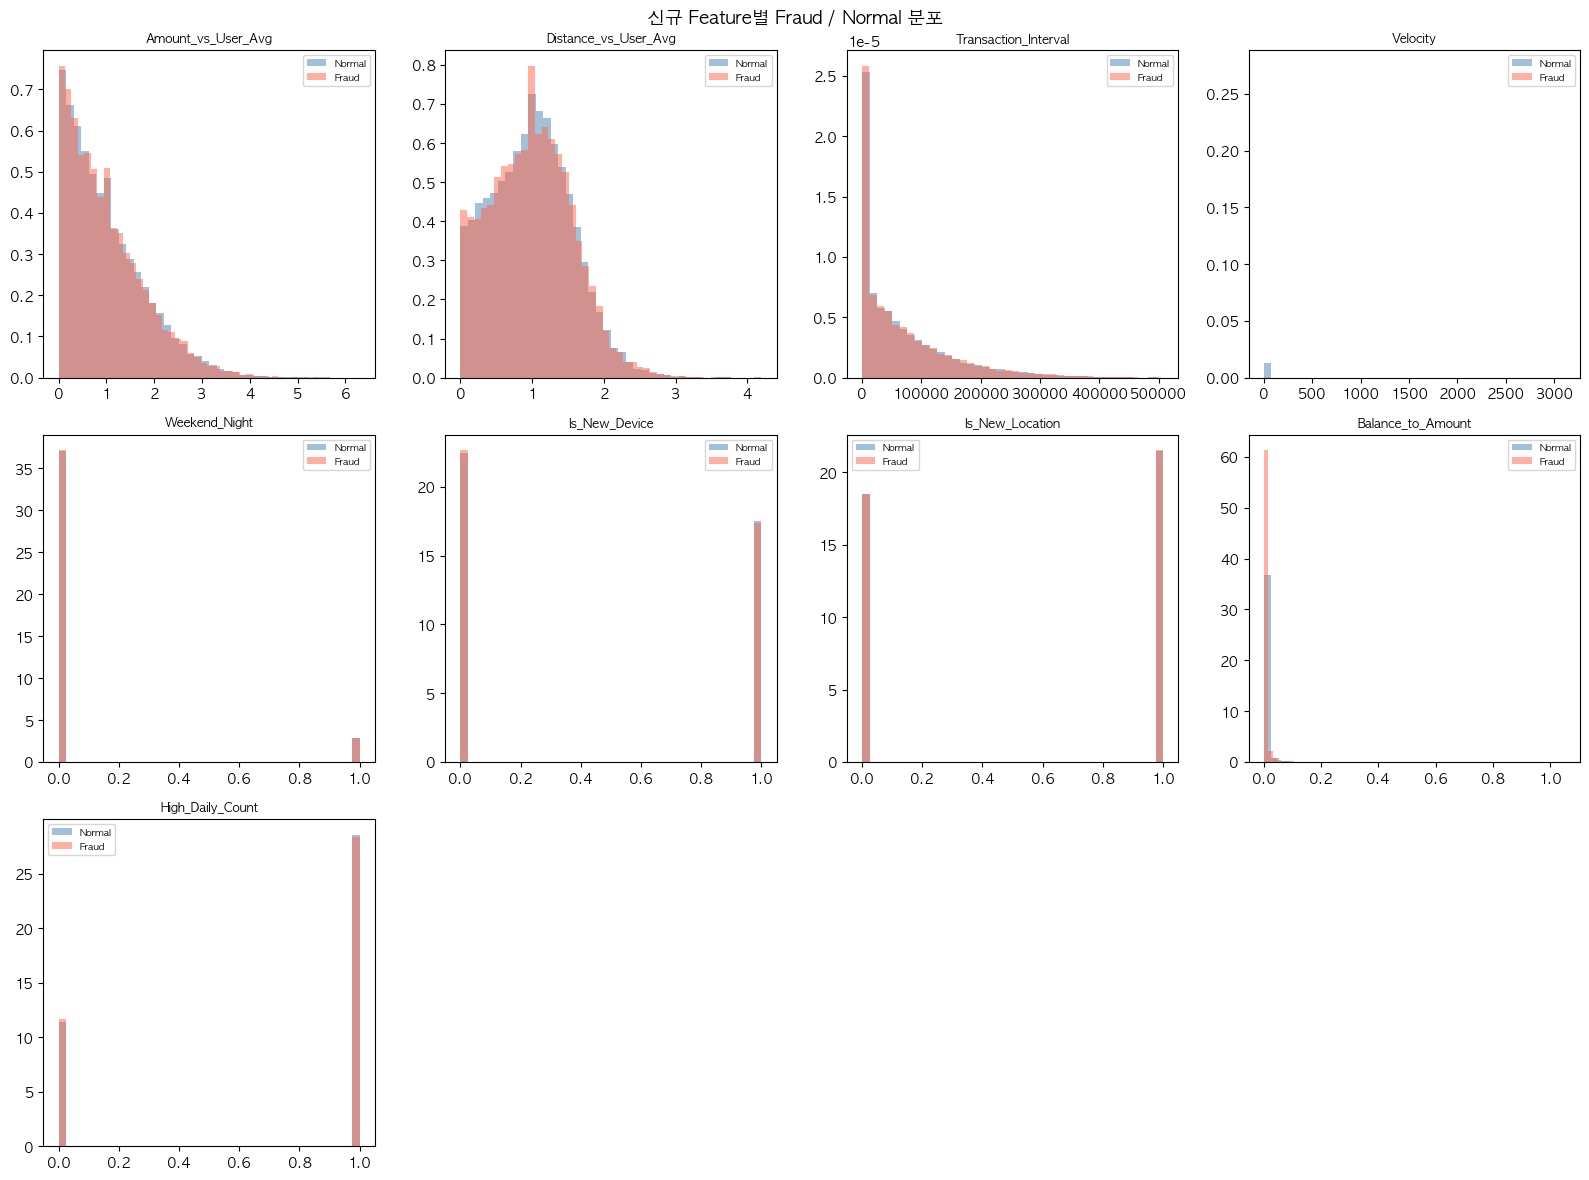

In [61]:
# 신규 feature Fraud 분포 시각화
fig, axes=plt.subplots(3, 4, figsize=(16, 12))
axes=axes.flatten()
for i, feat in enumerate(NEW_FEATURES):
    ax=axes[i]
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        vals=train_fe.loc[train_fe['Fraud_Label']==label, feat]
        ax.hist(vals, bins=40, alpha=0.5, color=color, label=f'{"Normal" if label==0 else "Fraud"}', density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
for j in range(len(NEW_FEATURES), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('신규 Feature별 Fraud / Normal 분포', fontsize=13)
plt.tight_layout()
plt.show()



## 3. 인코딩 & 데이터 분리

3가지 실험 세트 구성:

| 실험명 | 내용 |
|---|---|
| `Baseline_no_leakage` | Leakage 제거 + 기존 feature만 |
| `FE_added_no_leakage` | Leakage 제거 + 신규 feature 11개 추가 |


In [62]:

CAT_COLS=['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
DROP_COLS=['Transaction_ID', 'User_ID', 'Timestamp', 'prev_time', 'user_avg_amount', 'user_avg_distance', 'user_main_device', 'user_main_location']

def encode_and_split(tr, te):
    tr=tr.copy(); te=te.copy()
    for col in CAT_COLS:
        le=LabelEncoder()
        tr[col]=le.fit_transform(tr[col].astype(str))
        te[col]=le.transform(te[col].astype(str))
    tr=tr.drop(columns=[c for c in DROP_COLS if c in tr.columns])
    te=te.drop(columns=[c for c in DROP_COLS if c in te.columns])
    X_tr=tr.drop('Fraud_Label', axis=1).fillna(0).replace([np.inf, -np.inf], 0)
    y_tr=tr['Fraud_Label']
    X_te=te.drop('Fraud_Label', axis=1).fillna(0).replace([np.inf, -np.inf], 0)
    y_te=te['Fraud_Label']
    return X_tr, y_tr, X_te, y_te
print("=" * 50)
print(f"[Baseline] Feature 목록 ({len(BASE_COLS)}개)")
print("=" * 50)
for f in BASE_COLS:
    print(f"  {f}")

print()
print("=" * 50)
print(f"[FE Added] Feature 목록 ({len(X_tr.columns)}개)")
print("=" * 50)
for f in X_tr.columns:
    marker = " ★" if f in NEW_FEATURES else ""
    print(f"  {f}{marker}")

print()
print(f"★ 신규 추가 Feature ({len(NEW_FEATURES)}개): {NEW_FEATURES}")
X_tr, y_tr, X_te, y_te=encode_and_split(train_fe, test_fe)

BASE_COLS=[c for c in X_tr.columns if c not in NEW_FEATURES]
X_tr_base=X_tr[BASE_COLS]
X_te_base=X_te[BASE_COLS]

print(f"Baseline_no_leakage : X_train={X_tr_base.shape}")
print(f"FE_added_no_leakage : X_train={X_tr.shape}")


[Baseline] Feature 목록 (19개)
  Transaction_Amount
  Transaction_Type
  Account_Balance
  Device_Type
  Location
  Merchant_Category
  IP_Address_Flag
  Previous_Fraudulent_Activity
  Daily_Transaction_Count
  Avg_Transaction_Amount_7d
  Card_Type
  Card_Age
  Transaction_Distance
  Authentication_Method
  Is_Weekend
  Hour
  Day
  Month
  DayOfWeek

[FE Added] Feature 목록 (28개)
  Transaction_Amount
  Transaction_Type
  Account_Balance
  Device_Type
  Location
  Merchant_Category
  IP_Address_Flag
  Previous_Fraudulent_Activity
  Daily_Transaction_Count
  Avg_Transaction_Amount_7d
  Card_Type
  Card_Age
  Transaction_Distance
  Authentication_Method
  Is_Weekend
  Hour
  Day
  Month
  DayOfWeek
  Amount_vs_User_Avg ★
  Distance_vs_User_Avg ★
  Transaction_Interval ★
  Velocity ★
  Weekend_Night ★
  Is_New_Device ★
  Is_New_Location ★
  Balance_to_Amount ★
  High_Daily_Count ★

★ 신규 추가 Feature (9개): ['Amount_vs_User_Avg', 'Distance_vs_User_Avg', 'Transaction_Interval', 'Velocity', 'Weekend

## 4. 평가 유틸 함수

In [63]:

def evaluate(model, Xte, yte, model_name, exp_label, threshold=0.5):
    proba=model.predict_proba(Xte)[:, 1]
    pred=(proba>=threshold).astype(int)
    tn, fp, fn, tp=confusion_matrix(yte, pred).ravel()
    return {
        'Model': model_name, 'Dataset': exp_label, 'Threshold': threshold,
        'AUC-ROC':round(roc_auc_score(yte, proba), 4),
        'AUC-PR':round(average_precision_score(yte, proba), 4),
        'Precision':round(precision_score(yte, pred, zero_division=0), 4),
        'Recall':round(recall_score(yte, pred), 4),
        'F1':round(f1_score(yte, pred), 4),
        'TN':int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
        '_proba': proba
    }

def plot_cm(vals, title, save_path=None):
    tn, fp, fn, tp=vals
    arr=np.array([[tn, fp], [fn, tp]])
    fig, ax=plt.subplots(figsize=(5, 4))
    im=ax.imshow(arr, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred 0','Pred 1'])
    ax.set_yticklabels(['True 0','True 1'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{arr[i,j]:,}', ha='center', va='center', fontsize=13, color='white' if arr[i,j] > arr.max()/2 else 'black')
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_roc_pr(proba, yte, title, save_path=None):
    fig, axes=plt.subplots(1, 2, figsize=(12, 5))
    fpr, tpr, _=roc_curve(yte, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f'AUC={roc_auc_score(yte, proba):.4f}')
    axes[0].plot([0,1],[0,1],'k--')
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title(f'ROC Curve — {title}'); axes[0].legend()
    prec, rec, _=precision_recall_curve(yte, proba)
    axes[1].plot(rec, prec, lw=2, label=f'AP={average_precision_score(yte, proba):.4f}')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title(f'PR Curve — {title}'); axes[1].legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("평가 함수 정의 완료")


평가 함수 정의 완료


## 5. 모델 학습


[실험: Baseline_no_leakage]

  ── XGBoost ──
  AUC-ROC=0.5068, AUC-PR=0.329, Recall=0.0626, Precision=0.3478, F1=0.106


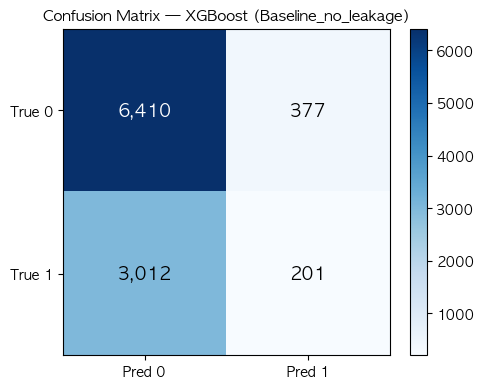

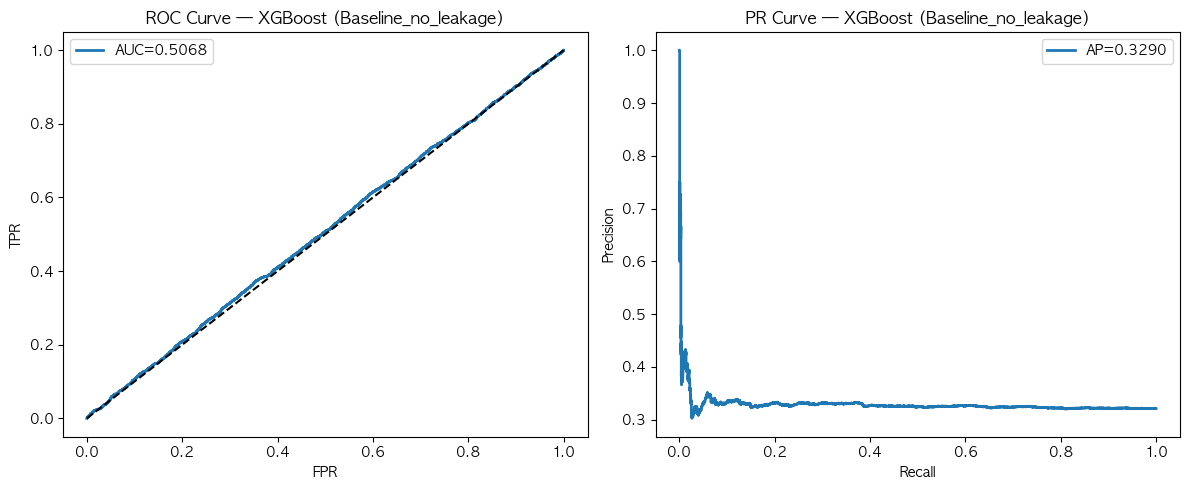


  ── LightGBM ──
  AUC-ROC=0.5037, AUC-PR=0.3279, Recall=0.0044, Precision=0.4516, F1=0.0086


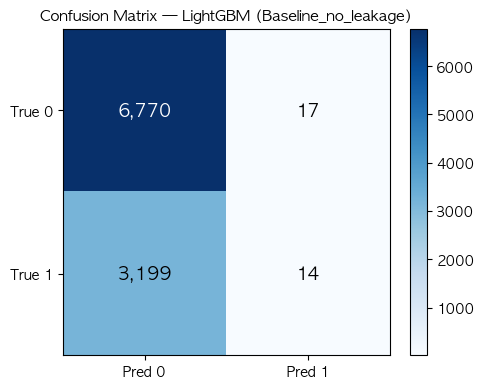

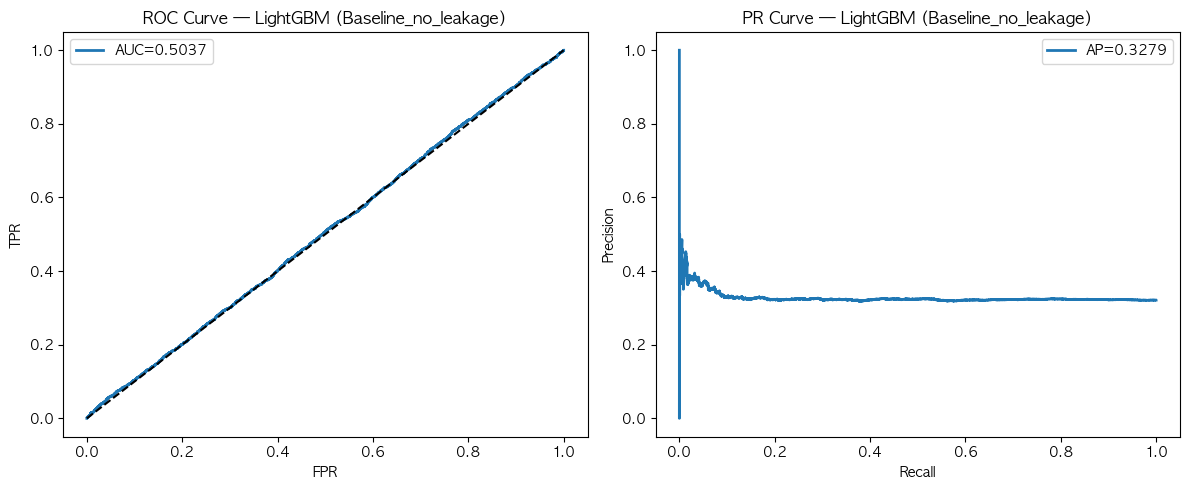


  ── RandomForest ──
  AUC-ROC=0.4983, AUC-PR=0.3203, Recall=0.0056, Precision=0.2727, F1=0.011


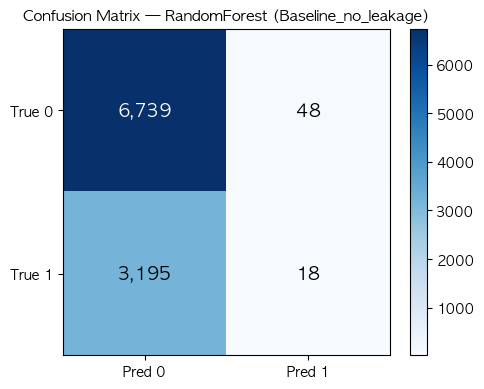

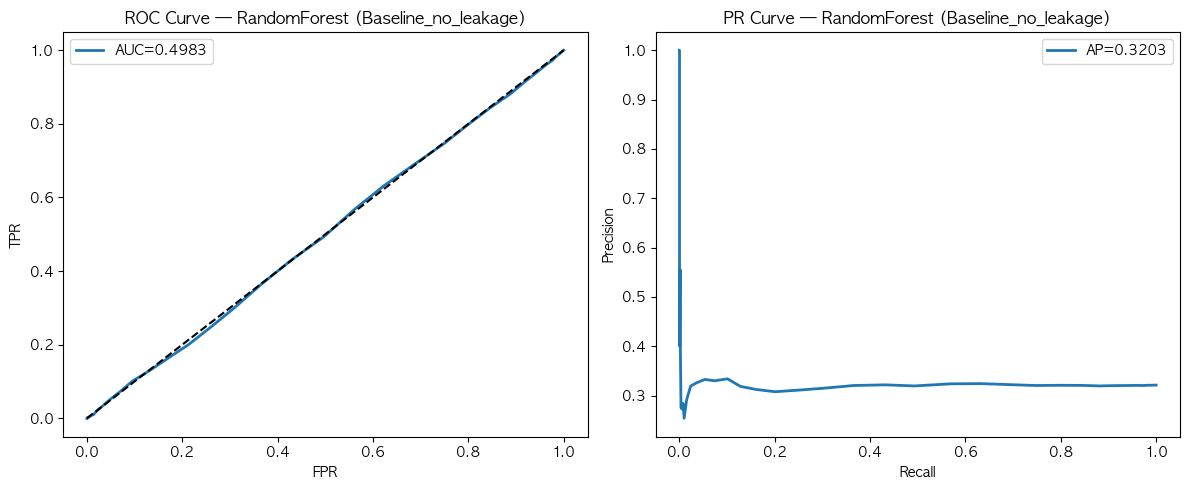


[실험: FE_added_no_leakage]

  ── XGBoost ──
  AUC-ROC=0.501, AUC-PR=0.321, Recall=0.0719, Precision=0.3004, F1=0.116


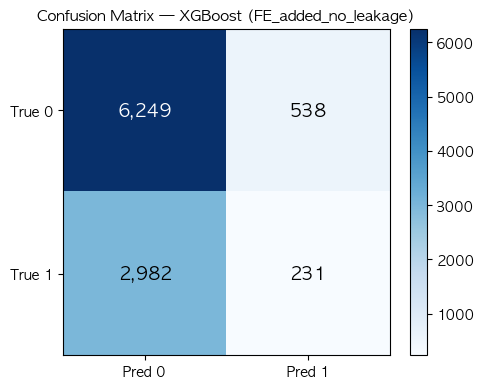

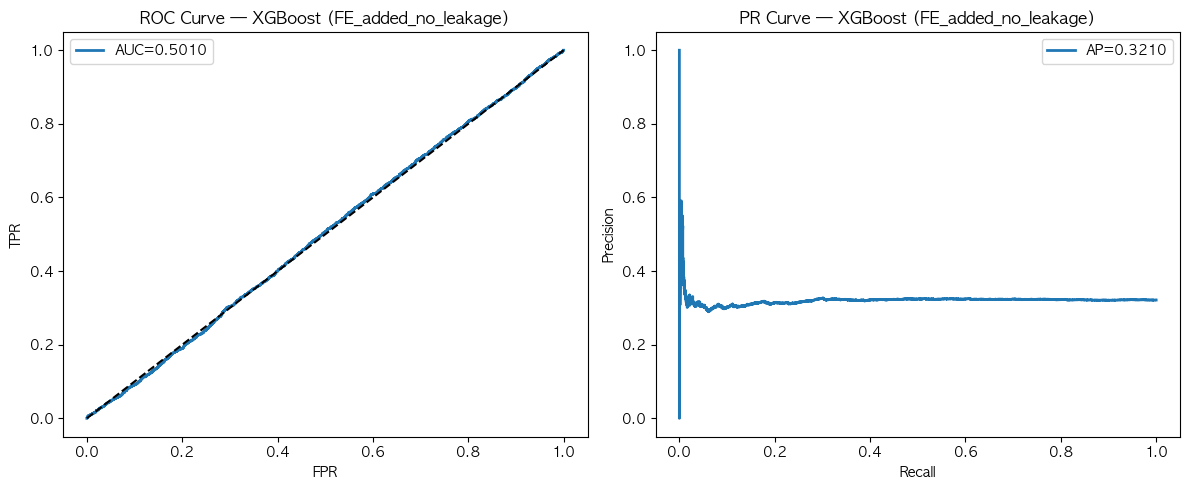


  ── LightGBM ──
  AUC-ROC=0.4994, AUC-PR=0.3202, Recall=0.0031, Precision=0.2703, F1=0.0062


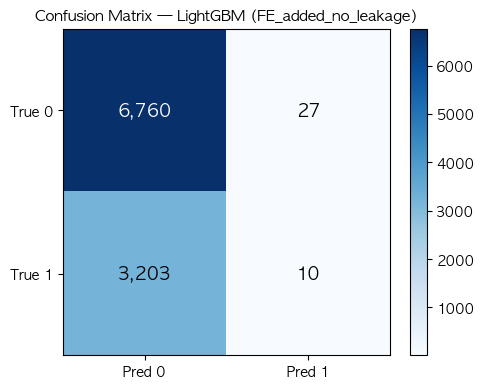

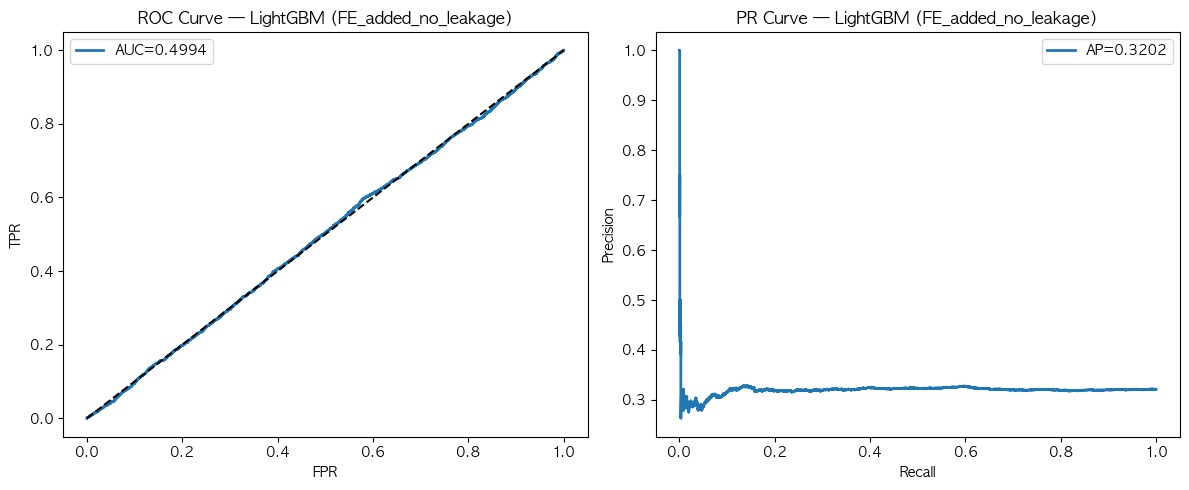


  ── RandomForest ──
  AUC-ROC=0.4906, AUC-PR=0.3176, Recall=0.0124, Precision=0.3478, F1=0.024


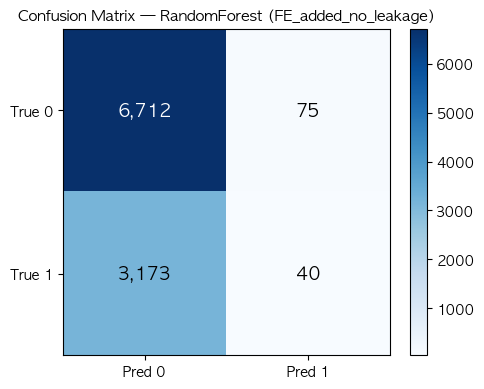

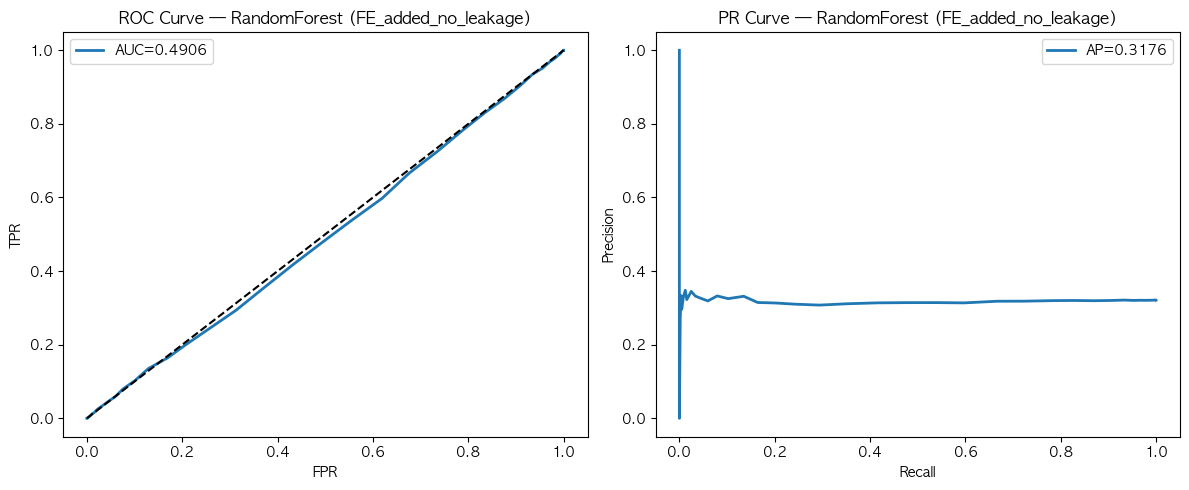

In [64]:

MODELS={
    'XGBoost': XGBClassifier(
        eval_metric='logloss',
        random_state=42, n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        random_state=42, n_jobs=-1
    ),
}

EXPERIMENTS=[
    ('Baseline_no_leakage', X_tr_base, y_tr, X_te_base, y_te),
    ('FE_added_no_leakage', X_tr, y_tr, X_te, y_te),
]

all_results=[]
trained_models={}

thresholds_list=np.round(np.arange(0.1, 0.95, 0.05), 2)

for exp_label, Xtr, Ytr, Xte, Yte in EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"[실험: {exp_label}]")
    print(f"{'='*60}")

    for mname, model in MODELS.items():
        m=copy.deepcopy(model)
        m.fit(Xtr, Ytr)
        r=evaluate(m, Xte, Yte, mname, exp_label)
        all_results.append(r)
        trained_models[(mname, exp_label)]=(m, Xte, Yte)

        print(f"\n  ── {mname} ──")
        print(f"  AUC-ROC={r['AUC-ROC']}, AUC-PR={r['AUC-PR']}, "
              f"Recall={r['Recall']}, Precision={r['Precision']}, F1={r['F1']}")

        proba = r['_proba']
        safe = f'{mname}_{exp_label}'

        # ── (1) Confusion Matrix ──────────────────────────────
        plot_cm((r['TN'],r['FP'],r['FN'],r['TP']),
                f'Confusion Matrix — {mname} ({exp_label})',
                save_path=f'results/figures/confusion_matrix/cm_{safe}.png')

        # ── (2) ROC / PR Curve ────────────────────────────────
        plot_roc_pr(proba, Yte, f'{mname} ({exp_label})',
                    save_path=f'results/figures/roc_pr/roc_pr_{safe}.png')



In [65]:
# 결과 DataFrame & 저장
METRIC_COLS=['Model','Dataset','Threshold','AUC-ROC','AUC-PR', 'Precision','Recall','F1','TN','FP','FN','TP']
metrics_df=pd.DataFrame([{k: r[k] for k in METRIC_COLS} for r in all_results])
metrics_df.to_csv('results/metrics/model_comparison.csv', index=False)

# 전체 요약 출력
print("\n[전체 실험 결과 요약]")
display(metrics_df[['Model','Dataset','AUC-ROC','AUC-PR','Precision','Recall','F1']].sort_values(['Dataset','F1'], ascending=[True,False]))



[전체 실험 결과 요약]


,Model,Dataset,AUC-ROC,AUC-PR,Precision,Recall,F1
0,XGBoost,Baseline_no_leakage,0.5068,0.3290,0.3478,0.0626,0.1060
2,RandomForest,Baseline_no_leakage,0.4983,0.3203,0.2727,0.0056,0.0110
1,LightGBM,Baseline_no_leakage,0.5037,0.3279,0.4516,0.0044,0.0086
3,XGBoost,FE_added_no_leakage,0.5010,0.3210,0.3004,0.0719,0.1160
5,RandomForest,FE_added_no_leakage,0.4906,0.3176,0.3478,0.0124,0.0240
4,LightGBM,FE_added_no_leakage,0.4994,0.3202,0.2703,0.0031,0.0062


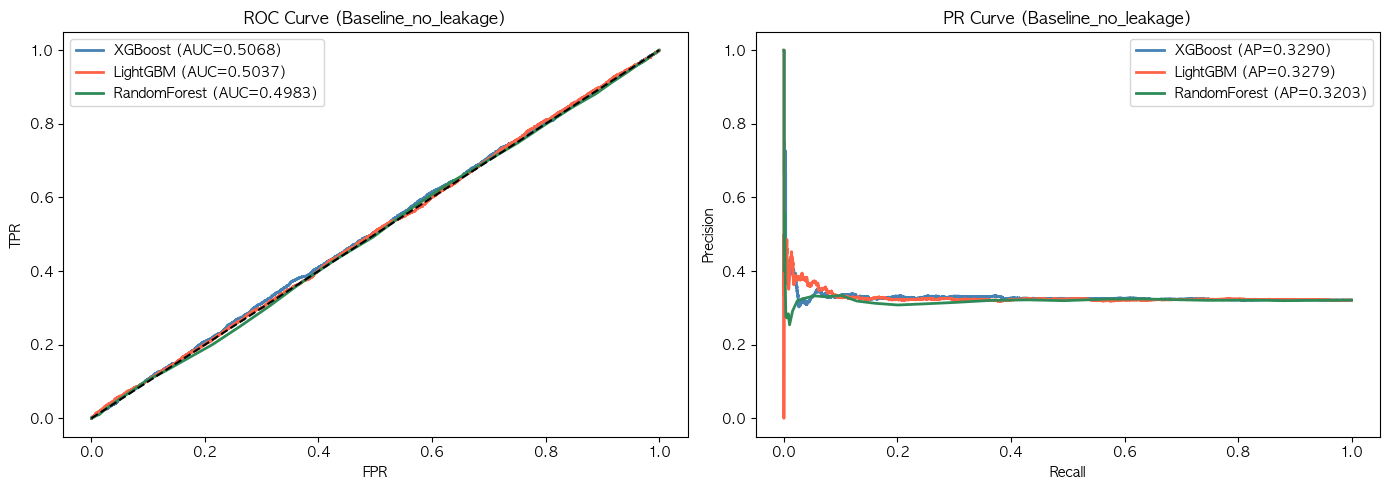

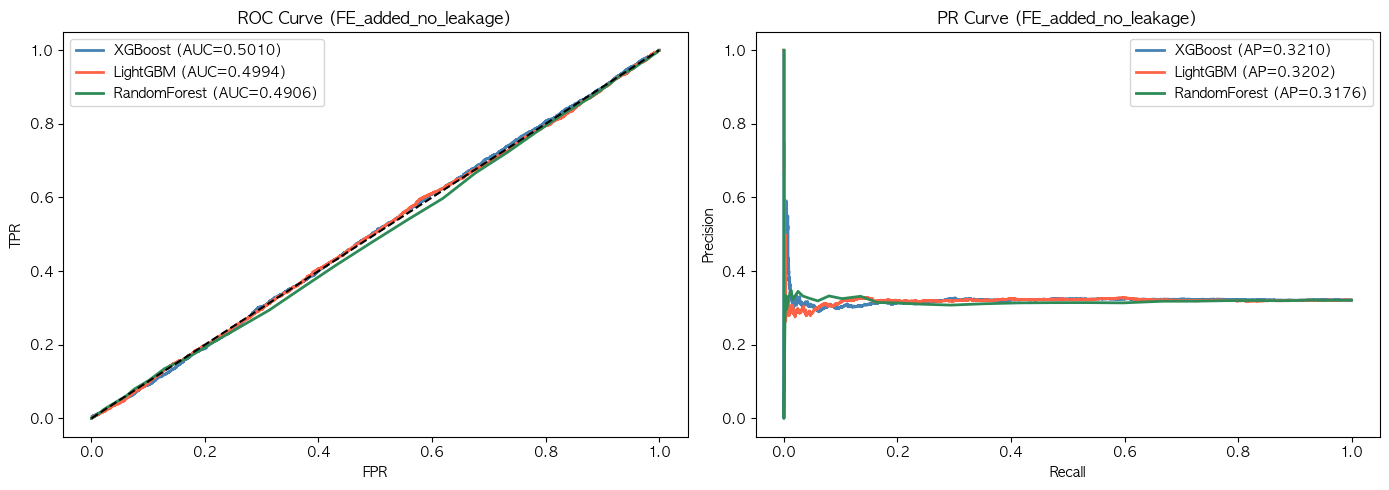

In [66]:
# ROC / PR 곡선 — 실험별 3개 모델 비교
colors=['steelblue', 'tomato', 'seagreen']

for exp_label, _, _, _, _ in EXPERIMENTS:
    fig, axes=plt.subplots(1, 2, figsize=(14, 5))
    for mname, color in zip(['XGBoost','LightGBM','RandomForest'], colors):
        model, Xte, Yte=trained_models[(mname, exp_label)]
        proba=model.predict_proba(Xte)[:,1]
        fpr, tpr, _=roc_curve(Yte, proba)
        prec, rec, _=precision_recall_curve(Yte, proba)
        axes[0].plot(fpr, tpr, lw=2, color=color,
                     label=f'{mname} (AUC={roc_auc_score(Yte,proba):.4f})')
        axes[1].plot(rec, prec, lw=2, color=color,
                     label=f'{mname} (AP={average_precision_score(Yte,proba):.4f})')
    axes[0].plot([0,1],[0,1],'k--'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title(f'ROC Curve ({exp_label})'); axes[0].legend()
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title(f'PR Curve ({exp_label})'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'results/figures/roc_pr/roc_pr_compare_{exp_label}.png', dpi=150, bbox_inches='tight')
    plt.show()


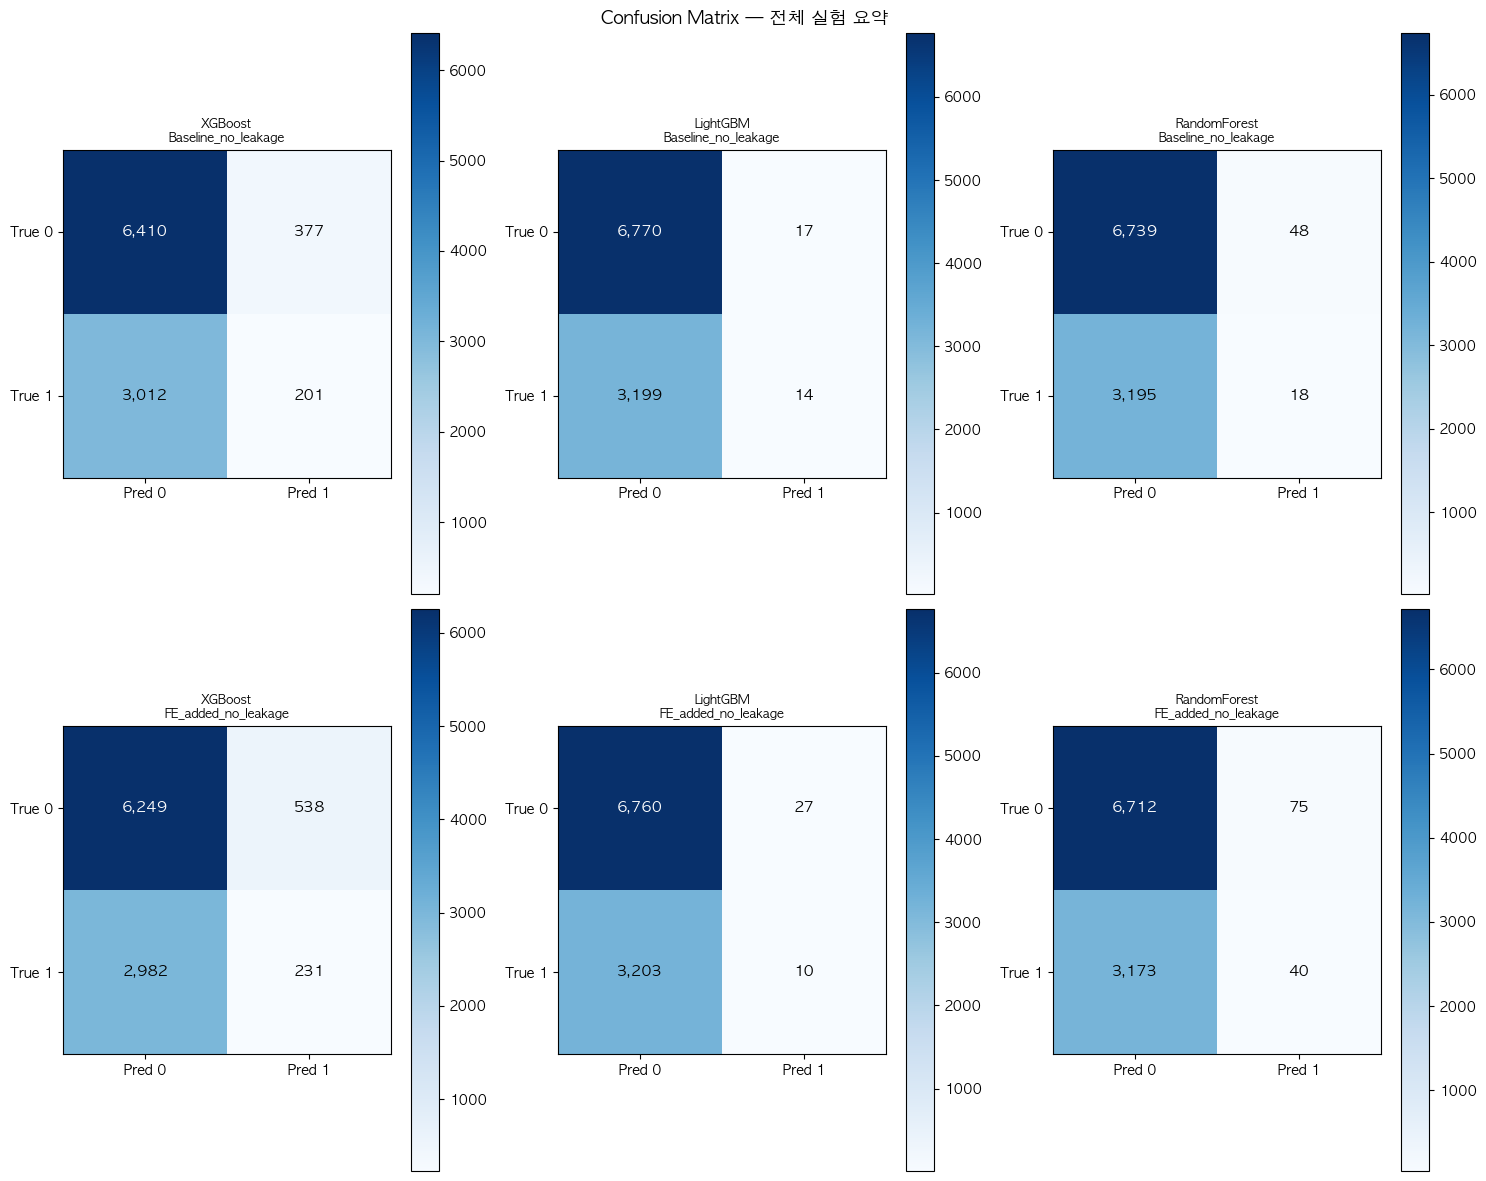

In [67]:
# Confusion Matrix 요약 — 모든 실험×모델 (grid)
fig, axes=plt.subplots(2, 3, figsize=(15, 12))
exp_names=[e[0] for e in EXPERIMENTS]
model_names=['XGBoost','LightGBM','RandomForest']

for row_i, exp_label in enumerate(exp_names):
    for col_j, mname in enumerate(model_names):
        r=next(x for x in all_results if x['Model']==mname and x['Dataset']==exp_label)
        arr=np.array([[r['TN'], r['FP']], [r['FN'], r['TP']]])
        ax=axes[row_i][col_j]
        im=ax.imshow(arr, cmap='Blues')
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Pred 0','Pred 1'])
        ax.set_yticklabels(['True 0','True 1'])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f'{arr[i,j]:,}', ha='center', va='center',
                        fontsize=11, color='white' if arr[i,j]>arr.max()/2 else 'black')
        ax.set_title(f'{mname}\n{exp_label}', fontsize=9)
        plt.colorbar(im, ax=ax)

plt.suptitle('Confusion Matrix — 전체 실험 요약', fontsize=13)
plt.tight_layout()
plt.savefig('results/figures/confusion_matrix/cm_all_grid.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Threshold Tuning

- threshold를 낮추면 Recall ↑, Precision ↓ (FP 증가)
- threshold를 높이면 Precision ↑, Recall ↓ (FN 증가)
- 사기 탐지에서는 Recall이 중요하지만 FP가 너무 많으면 실무에서 사용 불가 → 균형 찾기


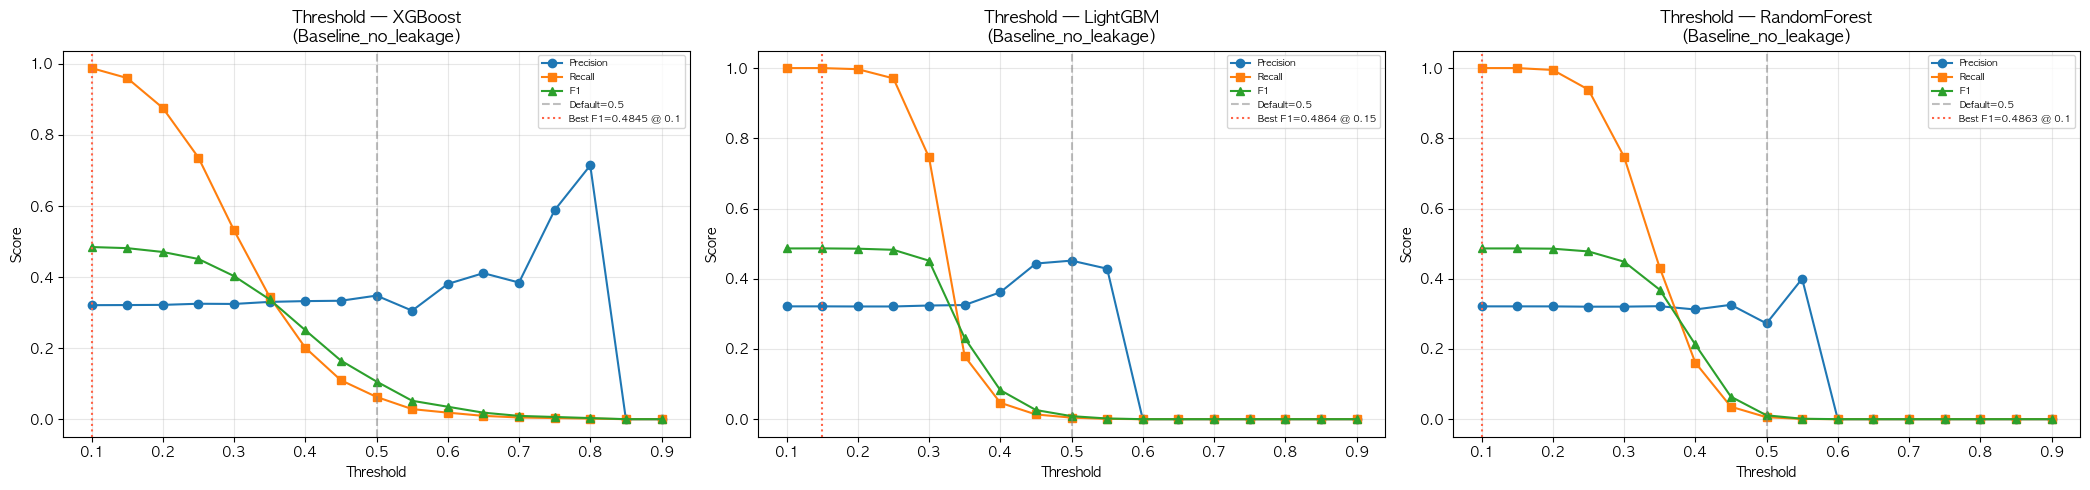

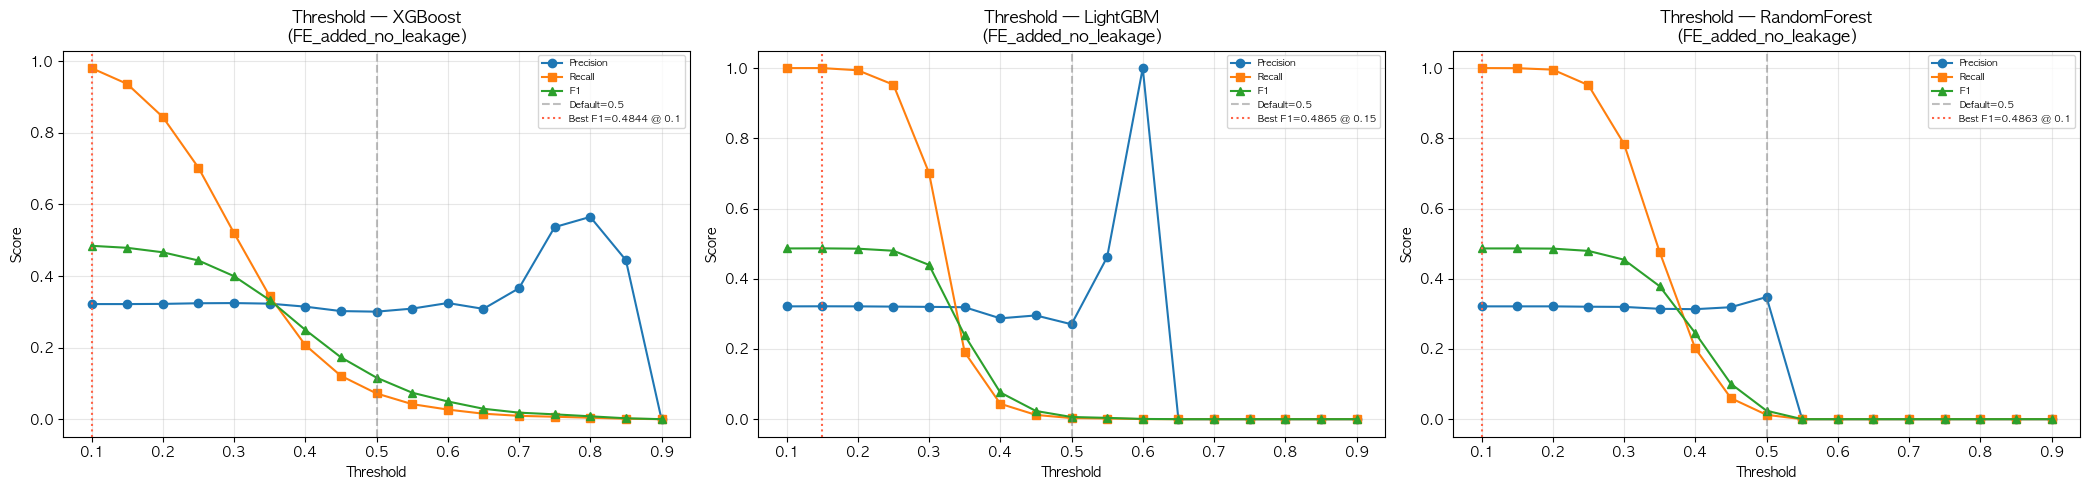

저장: results/metrics/threshold_tuning_all.csv


In [68]:
# Threshold Tuning — 모든 실험 (섹션 5에서 이미 개별 출력됨 / 여기서는 실험별 비교)
thresholds=np.round(np.arange(0.1, 0.95, 0.05), 2)
thr_rows=[]

for exp_label, _, _, _, _ in EXPERIMENTS:
    fig, axes=plt.subplots(1, 3, figsize=(21, 5))
    for ax, mname in zip(axes, ['XGBoost', 'LightGBM', 'RandomForest']):
        model, Xte, Yte=trained_models[(mname, exp_label)]
        proba=model.predict_proba(Xte)[:, 1]
        rows=[]
        for thr in thresholds:
            pred=(proba>=thr).astype(int)
            rows.append({
                'Experiment': exp_label, 'Model': mname, 'Threshold': thr,
                'Precision': round(precision_score(Yte, pred, zero_division=0), 4),
                'Recall':    round(recall_score(Yte, pred), 4),
                'F1':        round(f1_score(Yte, pred), 4),
            })
        thr_rows.extend(rows)
        df_thr=pd.DataFrame(rows)
        best=df_thr.loc[df_thr['F1'].idxmax()]

        ax.plot(df_thr['Threshold'], df_thr['Precision'], marker='o', label='Precision')
        ax.plot(df_thr['Threshold'], df_thr['Recall'],    marker='s', label='Recall')
        ax.plot(df_thr['Threshold'], df_thr['F1'],        marker='^', label='F1')
        ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default=0.5')
        ax.axvline(best['Threshold'], color='tomato', linestyle=':',
                   label=f"Best F1={best['F1']} @ {best['Threshold']}")
        ax.set_title(f'Threshold — {mname}\n({exp_label})')
        ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'results/figures/threshold/threshold_compare_{exp_label}.png', dpi=150, bbox_inches='tight')
    plt.show()

thr_df=pd.DataFrame(thr_rows)
thr_df.to_csv('results/metrics/threshold_tuning_all.csv', index=False)
print("저장: results/metrics/threshold_tuning_all.csv")


In [69]:
# 최적 threshold 표 — 모든 실험×모델
print(f"{'Experiment':<25} {'Model':<14} {'Best Thr':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print('-'*78)
for exp_label, _, _, _, _ in EXPERIMENTS:
    for mname in ['XGBoost', 'LightGBM', 'RandomForest']:
        sub=thr_df[(thr_df['Experiment']==exp_label) & (thr_df['Model']==mname)]
        best=sub.loc[sub['F1'].idxmax()]
        print(f"{exp_label:<25} {mname:<14} {best['Threshold']:>9} "
              f"{best['Precision']:>10} {best['Recall']:>8} {best['F1']:>8}")
    print()


Experiment                Model           Best Thr  Precision   Recall       F1
------------------------------------------------------------------------------
Baseline_no_leakage       XGBoost              0.1     0.3209   0.9882   0.4845
Baseline_no_leakage       LightGBM            0.15     0.3213      1.0   0.4864
Baseline_no_leakage       RandomForest         0.1     0.3213      1.0   0.4863

FE_added_no_leakage       XGBoost              0.1     0.3216    0.981   0.4844
FE_added_no_leakage       LightGBM            0.15     0.3215      1.0   0.4865
FE_added_no_leakage       RandomForest         0.1     0.3213      1.0   0.4863



## 7. Feature Importance & SHAP

- **Feature Importance**: 모델이 어떤 변수를 자주 사용했는지 (분기 횟수/gain 기반)
- **SHAP**: 각 변수가 개별 예측에 얼마나 어떤 방향으로 기여했는지 (방향성 포함)



[Feature Importance — Baseline_no_leakage]


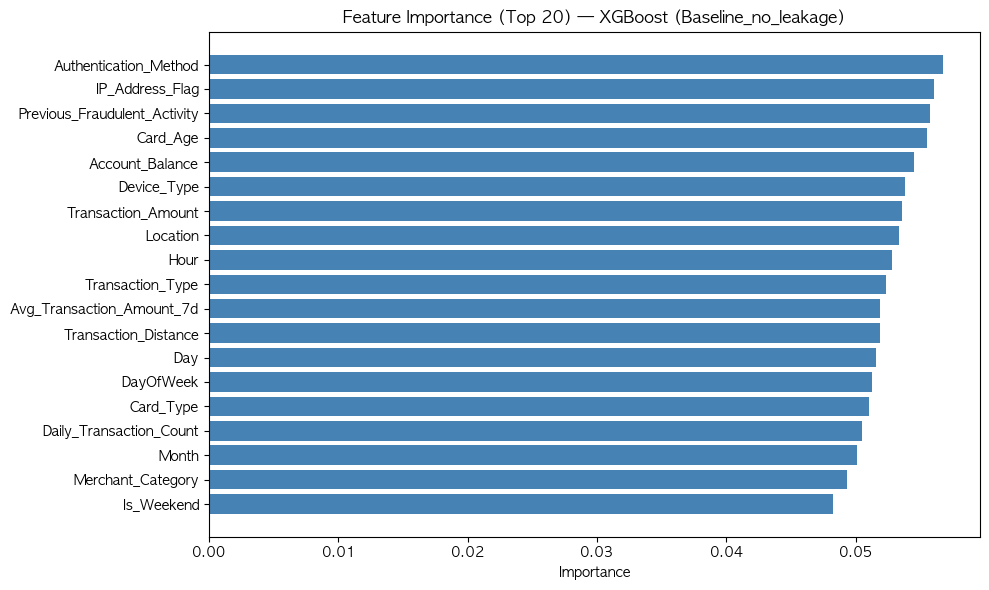

SHAP 계산 중: XGBoost (Baseline_no_leakage) ...


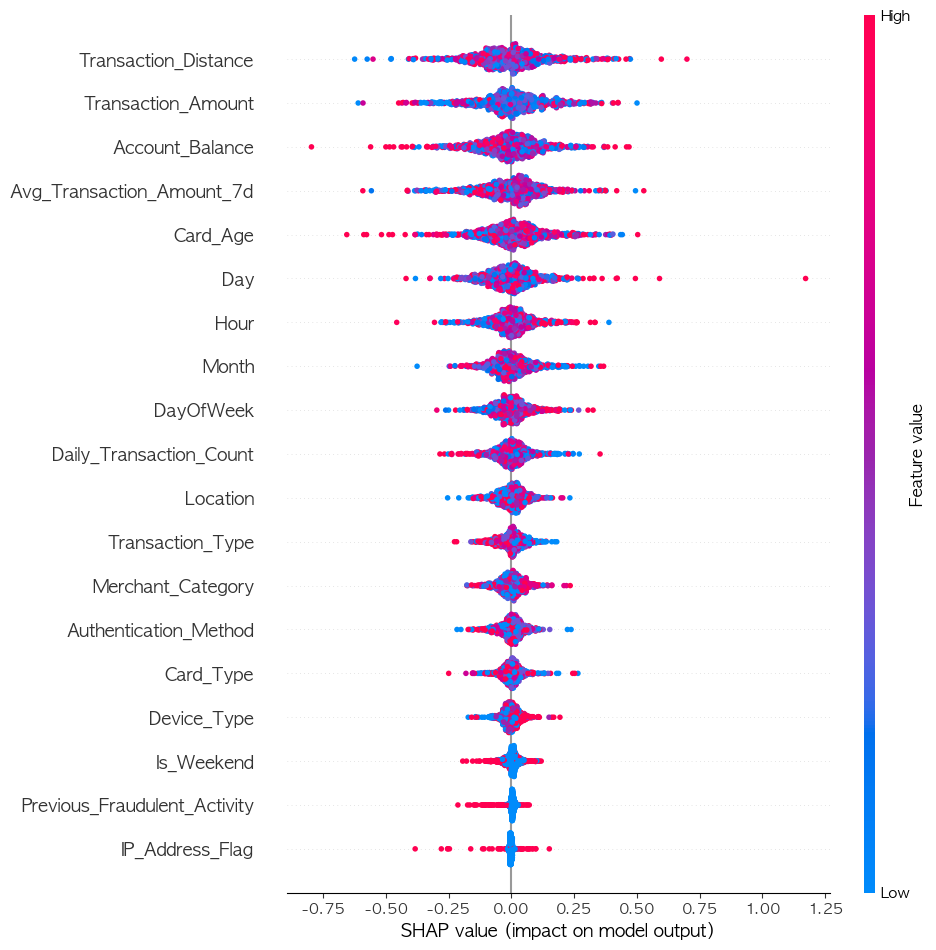

XGBoost (Baseline_no_leakage) 완료



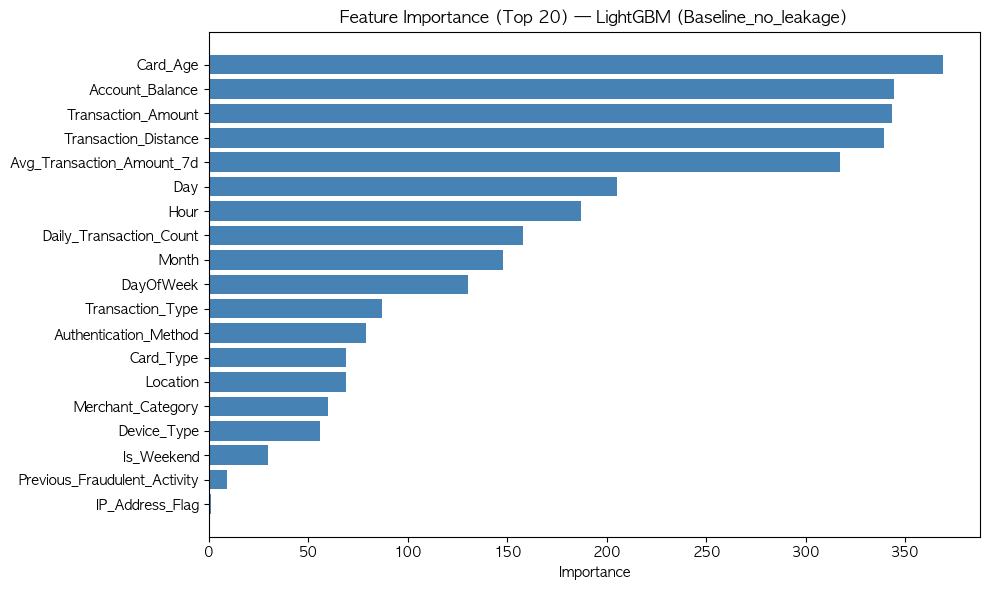

SHAP 계산 중: LightGBM (Baseline_no_leakage) ...


/Applications/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


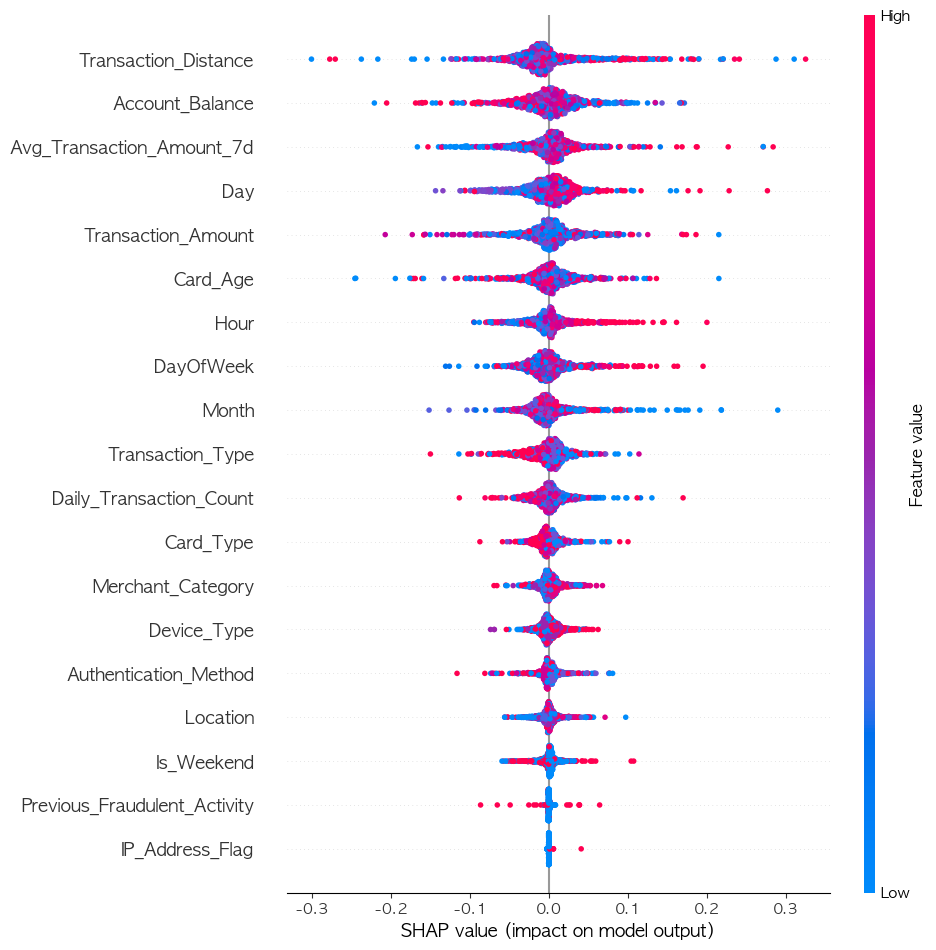

LightGBM (Baseline_no_leakage) 완료



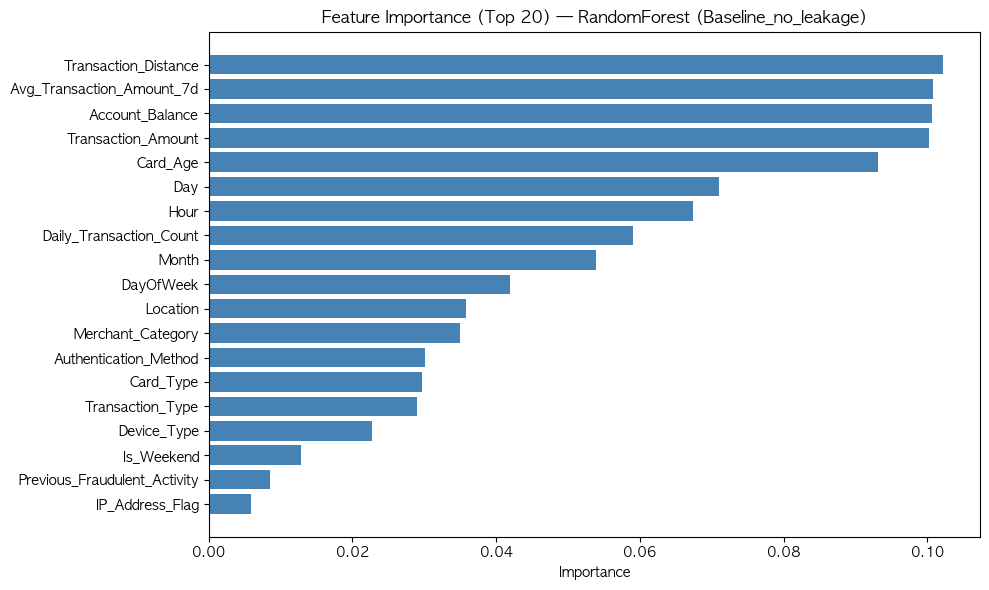

SHAP 계산 중: RandomForest (Baseline_no_leakage) ...


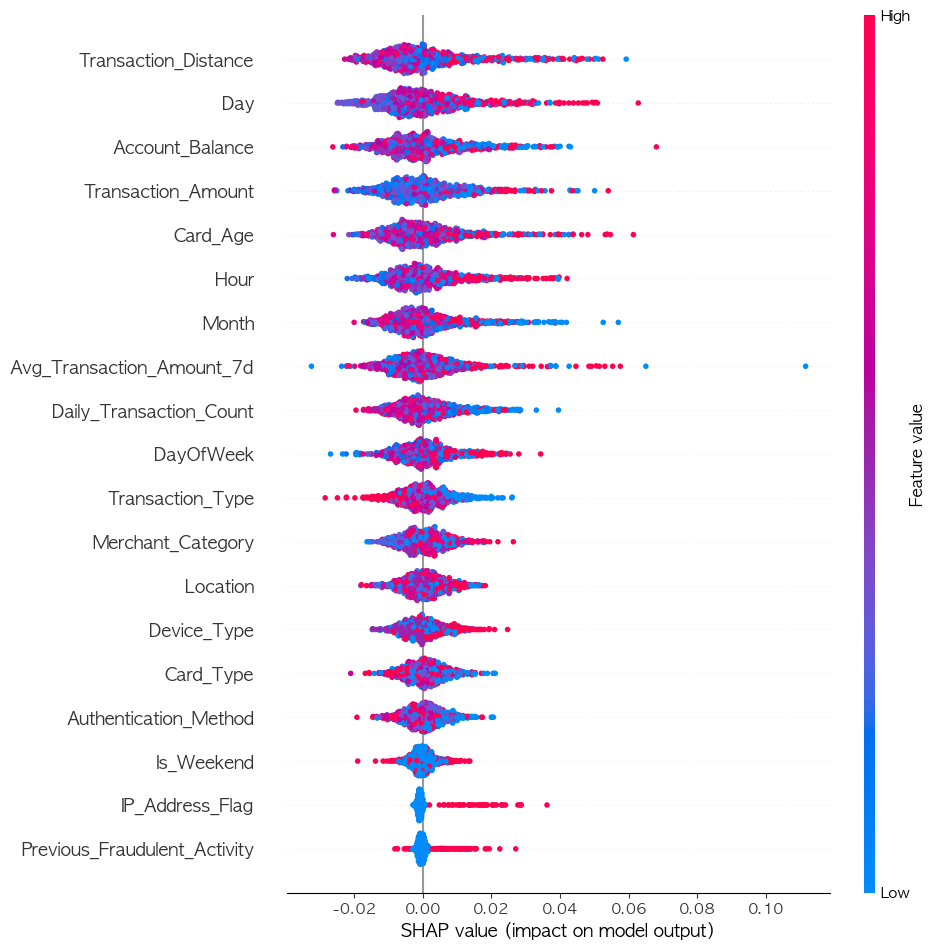

RandomForest (Baseline_no_leakage) 완료


[Feature Importance — FE_added_no_leakage]


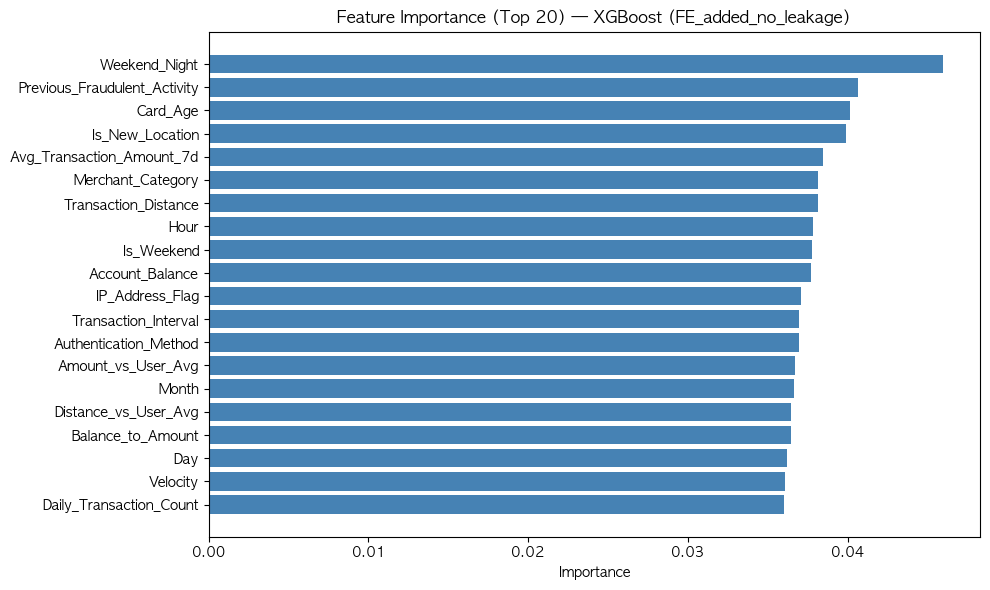

SHAP 계산 중: XGBoost (FE_added_no_leakage) ...


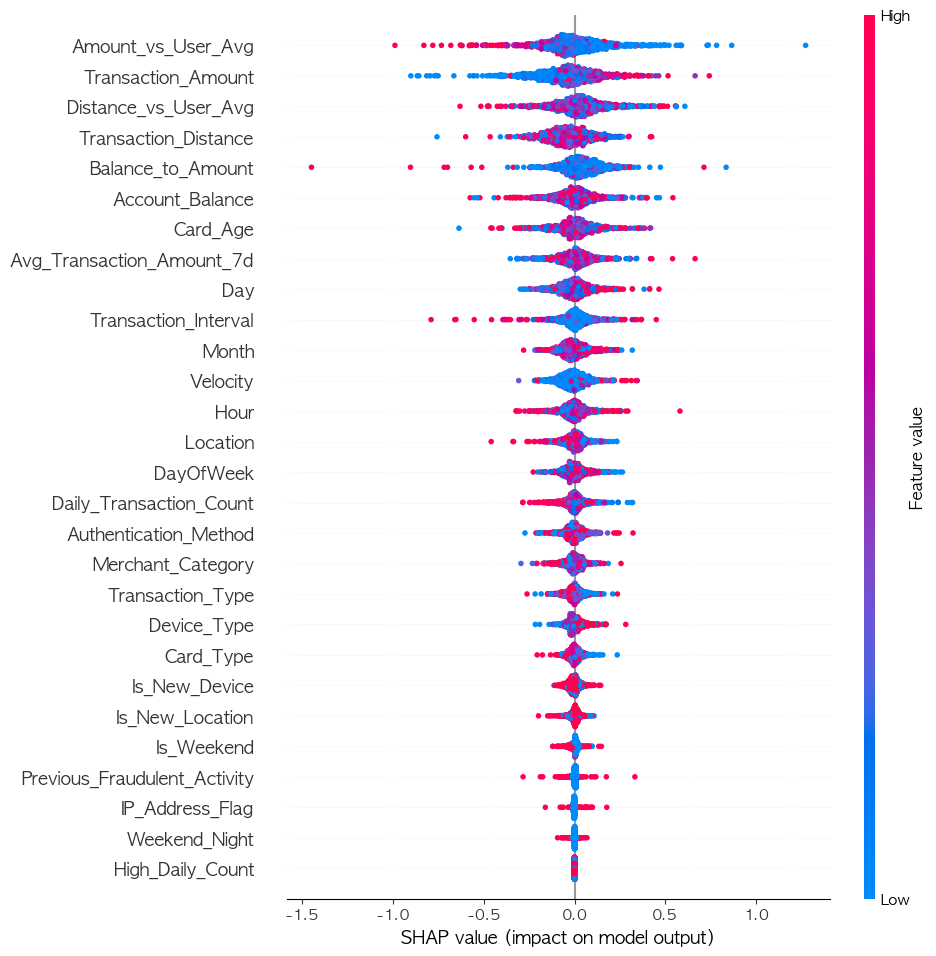

XGBoost (FE_added_no_leakage) 완료



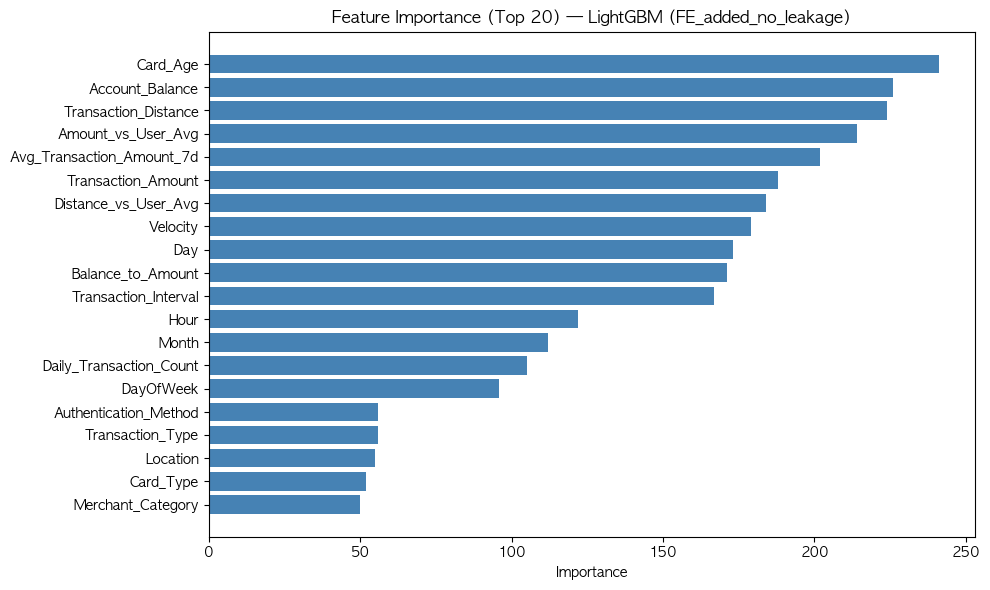

SHAP 계산 중: LightGBM (FE_added_no_leakage) ...


/Applications/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


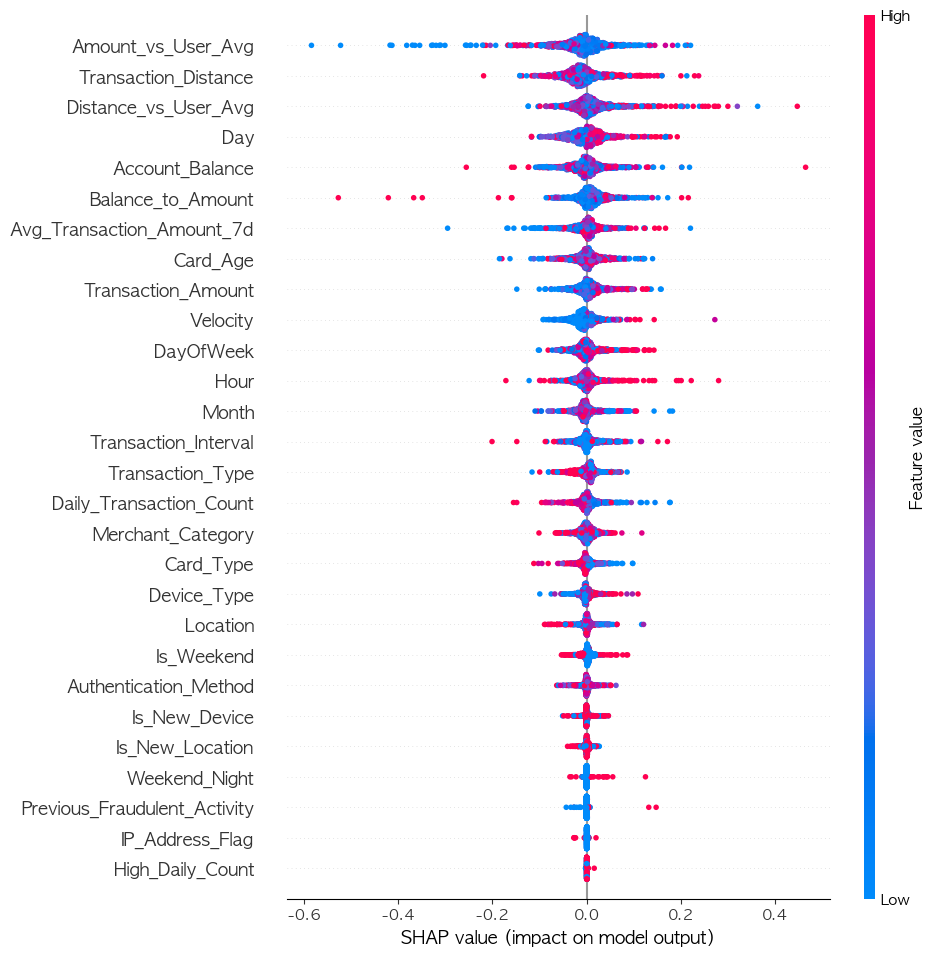

LightGBM (FE_added_no_leakage) 완료



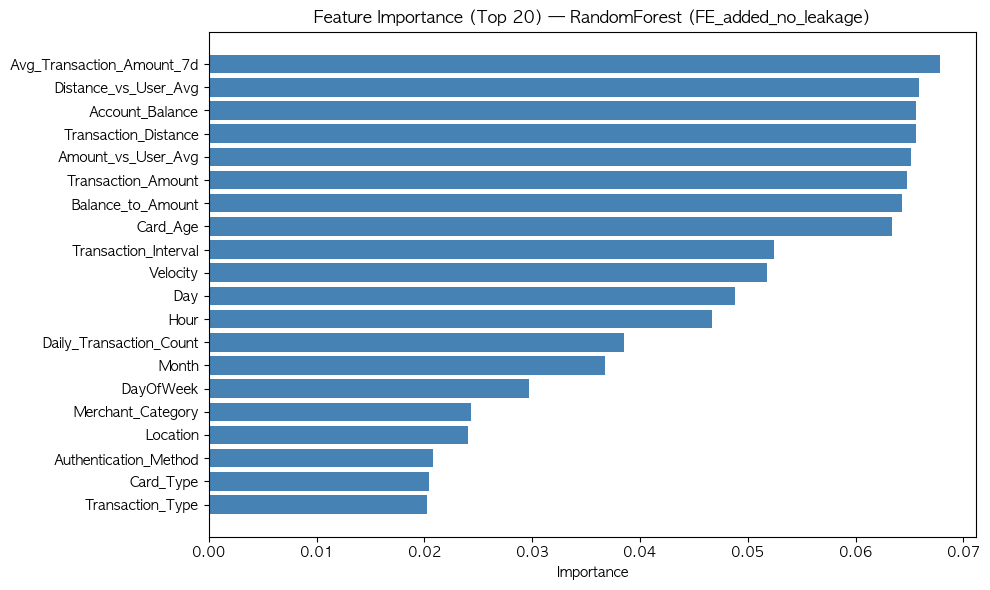

SHAP 계산 중: RandomForest (FE_added_no_leakage) ...


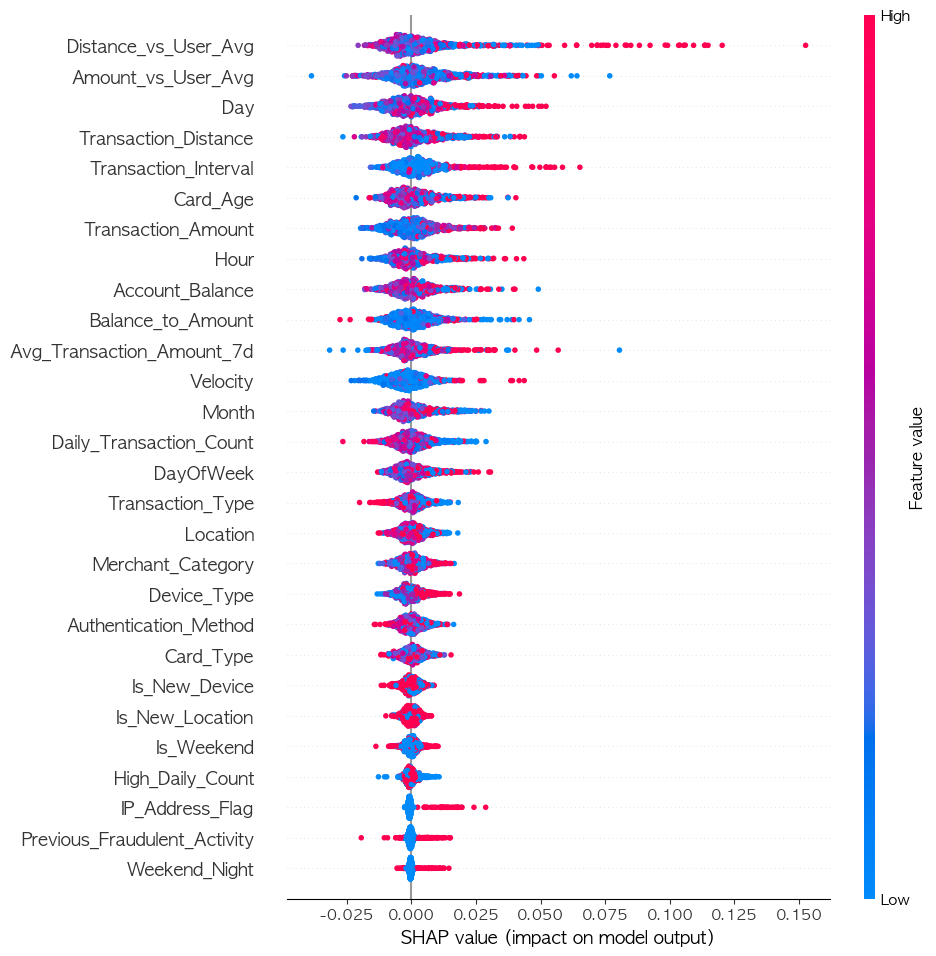

RandomForest (FE_added_no_leakage) 완료



In [70]:
import shap

for exp_label, _, _, _, _ in EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"[Feature Importance — {exp_label}]")
    print(f"{'='*60}")
    for mname in ['XGBoost', 'LightGBM', 'RandomForest']:
        model, Xte, Yte=trained_models[(mname, exp_label)]
        if not hasattr(model, 'feature_importances_'):
            continue

        safe = f'{mname}_{exp_label}'

        # Feature Importance
        imp=pd.DataFrame({'feature': Xte.columns,
                          'importance': model.feature_importances_}
                        ).sort_values('importance', ascending=False)
        imp.to_csv(f'results/metrics/feature_importance_{mname}_{exp_label}.csv', index=False)

        fig, ax=plt.subplots(figsize=(10, 6))
        top=imp.head(20)
        ax.barh(top['feature'][::-1], top['importance'][::-1], color='steelblue')
        ax.set_xlabel('Importance')
        ax.set_title(f'Feature Importance (Top 20) — {mname} ({exp_label})')
        plt.tight_layout()
        plt.savefig(f'results/figures/feature_importance/fi_{safe}.png', dpi=150, bbox_inches='tight')
        plt.show()

        # SHAP
        if mname in ['XGBoost', 'LightGBM', 'RandomForest']:
            print(f"SHAP 계산 중: {mname} ({exp_label}) ...")
            sample_idx=np.random.choice(len(Xte), min(1000, len(Xte)), replace=False)
            Xte_sample=Xte.iloc[sample_idx]
            explainer=shap.TreeExplainer(model)
            shap_values=explainer.shap_values(Xte_sample)
            if isinstance(shap_values, list):
                sv = shap_values[1]       # 구버전 shap — 클래스별 리스트
            elif shap_values.ndim == 3:
                sv = shap_values[:, :, 1] # 일부 버전 — (sample, feature, class) 3차원 배열
            else:
                sv = shap_values           # XGBoost/LightGBM 최신 버전 — 2차원 배열
            shap.summary_plot(sv, Xte_sample, show=False, max_display=Xte_sample.shape[1])
            fig=plt.gcf()
            fig.set_size_inches(14, 10)
            plt.subplots_adjust(right=0.85, bottom=0.1)
            plt.savefig(f'results/figures/feature_importance/shap_{safe}.png', dpi=150, bbox_inches='tight')
            plt.show()
            print(f"{mname} ({exp_label}) 완료\n")


## 8. Autoencoder (이상 탐지 비교)

**아이디어**: 정상 거래만으로 Autoencoder를 학습  
→ 정상 거래는 잘 복원되지만, 사기 거래는 복원 오류(reconstruction error)가 큼  
→ reconstruction error를 anomaly score처럼 사용해 supervised 모델과 비교

In [71]:
# ── 스케일링 ──────────────────────────────────────────────────
X_tr_normal=X_tr[y_tr==0].copy()
scaler=StandardScaler()
X_tr_sc=scaler.fit_transform(X_tr_normal)
X_te_sc=scaler.transform(X_te)

X_tr_tensor=torch.FloatTensor(X_tr_sc)
X_te_tensor=torch.FloatTensor(X_te_sc)

# ── 모델 정의 ─────────────────────────────────────────────────
n_feat=X_tr_sc.shape[1]

class Autoencoder(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.encoder=nn.Sequential(
            nn.Linear(n_feat, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
        )
        self.decoder=nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, n_feat),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

ae=Autoencoder(n_feat)
optimizer=torch.optim.Adam(ae.parameters(), lr=1e-3)
criterion=nn.MSELoss()

Epoch 5/50  Loss: 0.625384
Epoch 10/50  Loss: 0.580501
Epoch 15/50  Loss: 0.531284
Epoch 20/50  Loss: 0.519802
Epoch 25/50  Loss: 0.506282
Epoch 30/50  Loss: 0.502922
Epoch 35/50  Loss: 0.500879
Epoch 40/50  Loss: 0.504175
Epoch 45/50  Loss: 0.497494
Epoch 50/50  Loss: 0.493290


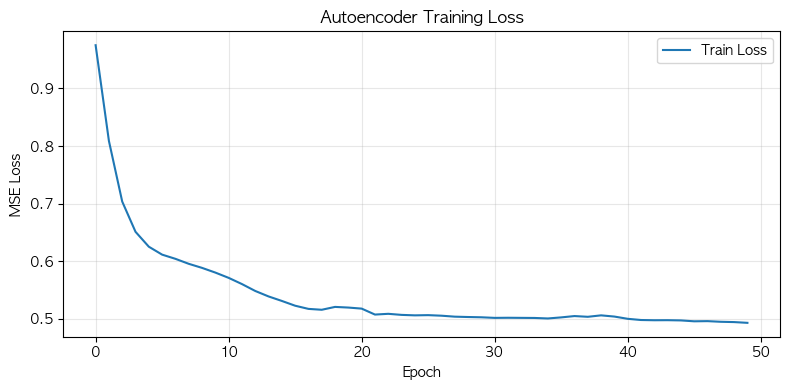


Autoencoder  AUC-ROC=0.5066,  AUC-PR=0.3242


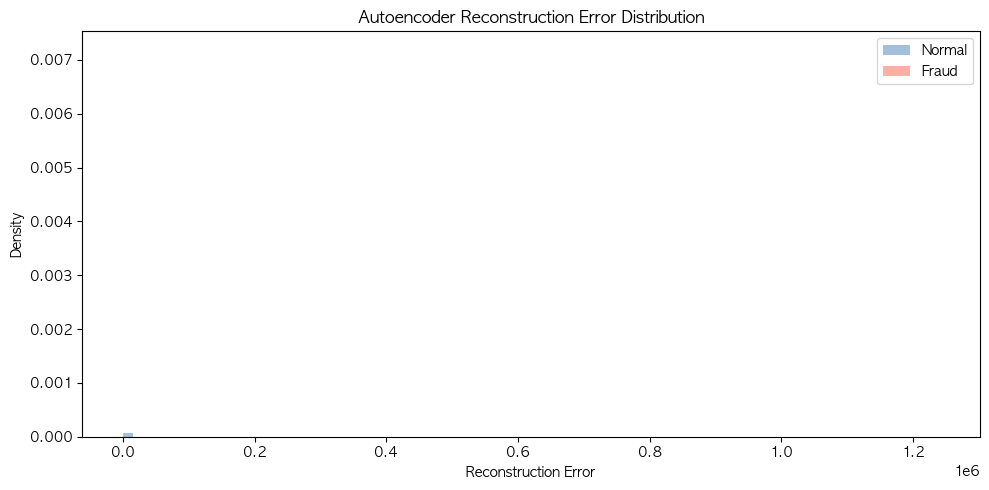

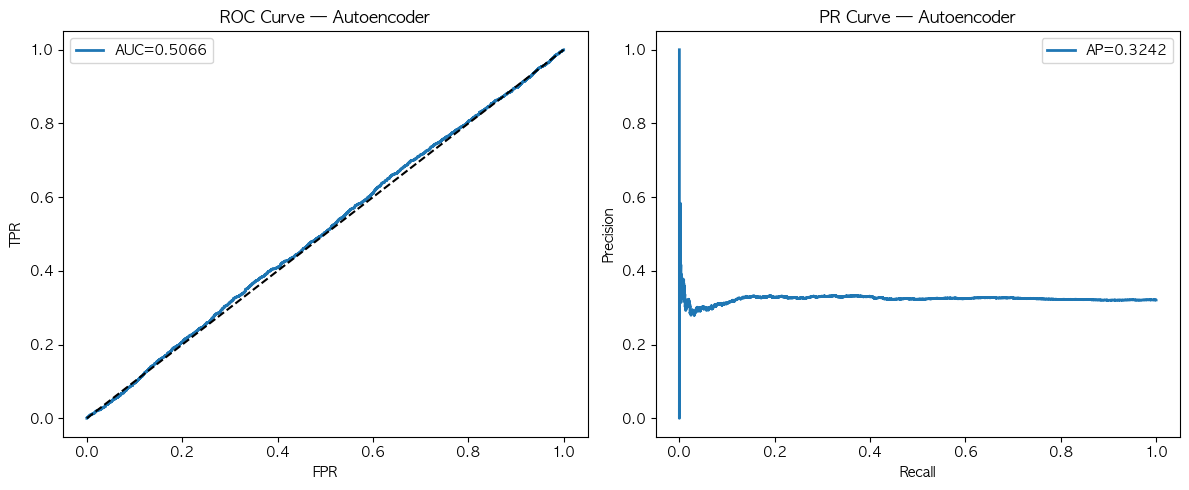

In [72]:
# ── 학습 ─────────────────────────────────────────────────────
EPOCHS=50
BATCH_SIZE=256
dataset=torch.utils.data.TensorDataset(X_tr_tensor)
loader=torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

train_losses=[]
ae.train()
for epoch in range(EPOCHS):
    epoch_loss=0
    for (batch,) in loader:
        optimizer.zero_grad()
        loss=criterion(ae(batch), batch)
        loss.backward()
        optimizer.step()
        epoch_loss+=loss.item()
    avg_loss=epoch_loss/len(loader)
    train_losses.append(avg_loss)
    if (epoch+1)%5==0:
        print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {avg_loss:.6f}")

# ── Loss curve ────────────────────────────────────────────────
fig, ax=plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train Loss')
ax.set_title('Autoencoder Training Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/autoencoder_train_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Reconstruction Error → Anomaly Score ─────────────────────
ae.eval()
with torch.no_grad():
    recon=ae(X_te_tensor).numpy()
recon_err=np.mean(np.square(X_te_sc-recon), axis=1)

ae_auc=roc_auc_score(y_te, recon_err)
ae_pr=average_precision_score(y_te, recon_err)
print(f"\nAutoencoder  AUC-ROC={ae_auc:.4f},  AUC-PR={ae_pr:.4f}")

# ── 분포 시각화 ───────────────────────────────────────────────
fig, ax=plt.subplots(figsize=(10, 5))
for lbl, mask, color in [('Normal', y_te==0, 'steelblue'), ('Fraud',  y_te==1, 'tomato')]:
    ax.hist(recon_err[mask], bins=80, alpha=0.5, label=lbl, color=color, density=True)
ax.set_xlabel('Reconstruction Error'); ax.set_ylabel('Density')
ax.set_title('Autoencoder Reconstruction Error Distribution')
ax.legend(); plt.tight_layout()
plt.savefig('results/figures/autoencoder_recon_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()


# ── ROC / PR Curve ────────────────────────────────────────────
plot_roc_pr(recon_err, y_te, 'Autoencoder',
            save_path='results/figures/roc_pr/roc_pr_Autoencoder.png')


## 9. Stacking (앙상블)

**아이디어**: 3개 모델의 예측 확률 → Logistic Regression meta 모델이 최종 판단

```
XGBoost  ──┐
LightGBM ──┼→ [P1, P2, P3] → LogisticRegression → 최종 예측
RF       ──┘
```

**5-fold OOF(Out-of-Fold)** 사용 이유:  
데이터 크기 대비 계산 비용과 안정성의 균형을 고려

In [73]:
kf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_xgb=np.zeros(len(y_tr))
oof_lgb=np.zeros(len(y_tr))
oof_rf=np.zeros(len(y_tr))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr)):
    Xf_tr, Xf_va=X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
    yf_tr=y_tr.iloc[tr_idx]

    xf = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0)
    lf = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    xf.fit(Xf_tr, yf_tr); lf.fit(Xf_tr, yf_tr); rf.fit(Xf_tr, yf_tr)
    oof_xgb[va_idx]=xf.predict_proba(Xf_va)[:,1]
    oof_lgb[va_idx]=lf.predict_proba(Xf_va)[:,1]
    oof_rf[va_idx]=rf.predict_proba(Xf_va)[:,1]
    print(f"Fold {fold+1}/5 완료")


Fold 1/5 완료
Fold 2/5 완료
Fold 3/5 완료
Fold 4/5 완료
Fold 5/5 완료


Stacking  AUC-ROC=0.4986,  Recall=0.0000,  Precision=0.0000,  F1=0.0000


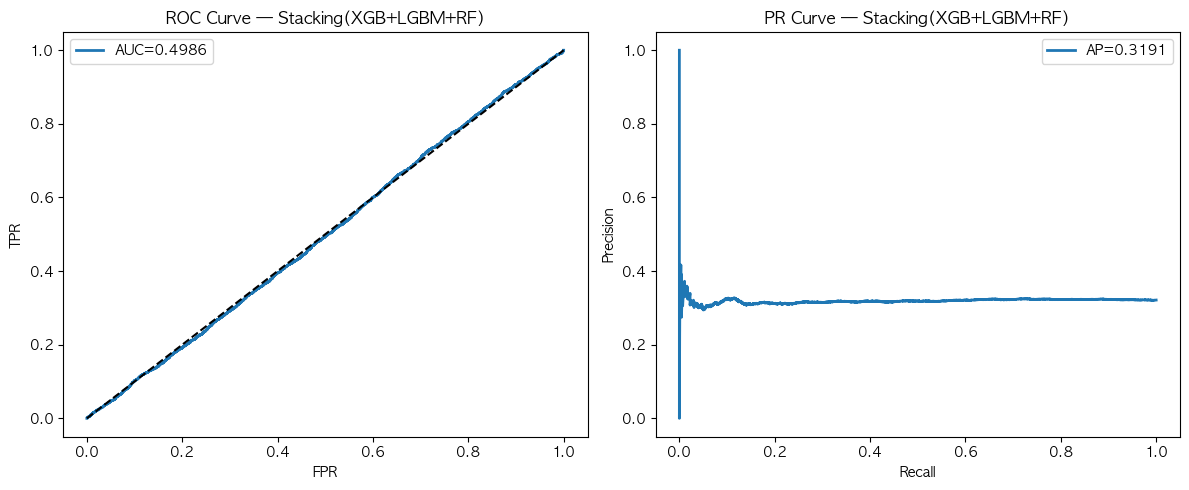

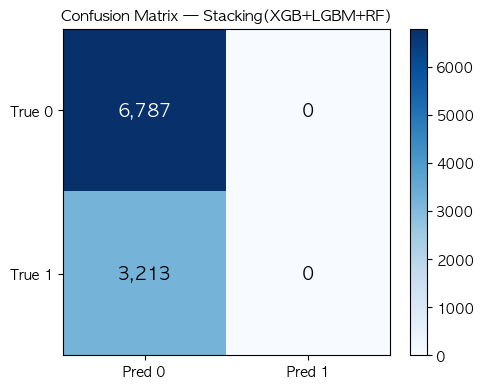

In [74]:
# 전체 train으로 학습된 모델로 test 예측
xgb_full=trained_models[('XGBoost', 'FE_added_no_leakage')][0]
lgb_full=trained_models[('LightGBM', 'FE_added_no_leakage')][0]
rf_full=trained_models[('RandomForest', 'FE_added_no_leakage')][0]

meta_tr=np.column_stack([oof_xgb, oof_lgb, oof_rf])
meta_te=np.column_stack([xgb_full.predict_proba(X_te)[:,1], lgb_full.predict_proba(X_te)[:,1], rf_full.predict_proba(X_te)[:,1]])

meta_clf=LogisticRegression(max_iter=500)
meta_clf.fit(meta_tr, y_tr)
st_proba=meta_clf.predict_proba(meta_te)[:,1]
st_pred=(st_proba>=0.5).astype(int)

tn_s, fp_s, fn_s, tp_s=confusion_matrix(y_te, st_pred).ravel()
st_auc=roc_auc_score(y_te, st_proba)
st_pr=average_precision_score(y_te, st_proba)
st_p=precision_score(y_te, st_pred, zero_division=0)
st_r=recall_score(y_te, st_pred)
st_f1=f1_score(y_te, st_pred)

print(f"Stacking  AUC-ROC={st_auc:.4f},  Recall={st_r:.4f},  "
      f"Precision={st_p:.4f},  F1={st_f1:.4f}")

plot_roc_pr(st_proba, y_te, 'Stacking(XGB+LGBM+RF)',
            save_path='results/figures/roc_pr/roc_pr_Stacking.png')
plot_cm((int(tn_s),int(fp_s),int(fn_s),int(tp_s)),
        'Confusion Matrix — Stacking(XGB+LGBM+RF)',
        save_path='results/figures/confusion_matrix/cm_Stacking.png')
